In [4]:
import os
import pandas as pd
import numpy as np
from glob import glob
from scipy.spatial.distance import jensenshannon

# === CONFIGURATION ===
root_dir = 'COO-Decon-Pseudobulks'
results_dir = os.path.join(root_dir, 'Results-JSD-PredictedVSActual')
os.makedirs(results_dir, exist_ok=True)

method_map = ['BayesPrism', 'nuSVR', 'ReDeconv', 'CIBERSORTx', 'MuSiC', 'NNLS', 'QP']

config_map = {
    "TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt": [
        "TSP-BDa_Outer_300_1500_10-Random_v2",
        "TSP-BDa_Outer_1000_3000_10-Random_v2",
        "TSP-BDa_Outer_3000_5000_10-Random_v2"
    ],
    "TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt": [
        "TSP-BDa_Inner_300_1500_10-Random_v2",
        "TSP-BDa_Inner_1000_3000_10-Random_v2",
        "TSP-BDa_Inner_3000_5000_10-Random_v2"
    ],
    "TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt": [
        "TSP-HBA_Inner_300_1500_10-Random_v2",
        "TSP-HBA_Inner_1000_3000_10-Random_v2",
        "TSP-HBA_Inner_3000_5000_10-Random_v2"
    ]
}

all_results = []

# === MAIN LOOP ===
for prop_file, input_dirs in config_map.items():
    prop_path = os.path.join(root_dir, prop_file)

    print(f"\n=== Processing proportions file: {prop_file} ===")

    prop_df = pd.read_csv(prop_path, sep='\t', index_col=0)

    prop_df.index = prop_df.index.astype(str).str.strip()
    prop_df.columns = prop_df.columns.astype(str).str.strip()

    if "TotalCells" in prop_df.columns:
        prop_df = prop_df.drop(columns=["TotalCells"])

    prop_df = prop_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    prop_sums = prop_df.sum(axis=1)

    if (prop_sums == 0).any():
        print(f"Warning: {(prop_sums == 0).sum()} true-proportion rows sum to zero in {prop_file}")

    prop_df = (
        prop_df
        .div(prop_sums.replace(0, np.nan), axis=0)
        .multiply(100)
        .round(5)
        .fillna(0)
    )

    for input_dir in input_dirs:
        decon_dir = os.path.join(root_dir, input_dir)
        decon_files = sorted(glob(os.path.join(decon_dir, '*_modified.txt')))

        if not decon_files:
            print(f"No decon files found in {decon_dir}")
            continue

        for file_path in decon_files:
            try:
                filename = os.path.basename(file_path)
                raw_method = filename.replace('_modified.txt', '')
                method = next((m for m in method_map if m in raw_method), raw_method)

                # Load decon results
                decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

                decon_df.index = decon_df.index.astype(str).str.strip()
                decon_df.columns = decon_df.columns.astype(str).str.strip()

                decon_df = decon_df.apply(pd.to_numeric, errors='coerce').fillna(0)

                # Align samples
                common_samples = prop_df.index.intersection(decon_df.index)

                if common_samples.empty:
                    print(f"No common samples in {file_path}")
                    continue

                # Identify column differences
                missing_in_decon = set(prop_df.columns) - set(decon_df.columns)
                missing_in_prop = set(decon_df.columns) - set(prop_df.columns)

                n_missing_in_decon = len(missing_in_decon)
                n_extra_in_decon = len(missing_in_prop)

                if missing_in_decon or missing_in_prop:
                    print(f"Column mismatch in {file_path}")
                    if missing_in_decon:
                        print(f"   Missing in decon: {missing_in_decon}")
                    if missing_in_prop:
                        print(f"   Missing in prop / extra in decon: {missing_in_prop}")

                # ============================================================
                # COLUMN ALIGNMENT FOR JSD
                # ============================================================
                # For MuSiC:
                #   Use the full expected cell-type space from prop_df.
                #   Missing expected MuSiC labels are added as predicted 0.
                #
                # For all other methods:
                #   Keep original behaviour: use only shared columns.
                # ============================================================

                if method == "MuSiC":
                    expected_cols = prop_df.columns

                    true_vals_df = prop_df.loc[common_samples, expected_cols].fillna(0)

                    pred_vals_df = (
                        decon_df
                        .reindex(index=common_samples, columns=expected_cols, fill_value=0)
                        .fillna(0)
                    )

                    if missing_in_decon:
                        print(f"   MuSiC missing labels added as 0 for JSD: {missing_in_decon}")

                else:
                    common_cols = prop_df.columns.intersection(decon_df.columns)

                    if common_cols.empty:
                        print(f"No matching columns in {file_path}")
                        continue

                    true_vals_df = prop_df.loc[common_samples, common_cols].fillna(0)
                    pred_vals_df = decon_df.loc[common_samples, common_cols].fillna(0)

                sample_jsd = []
                skipped_samples = 0

                for sample in common_samples:
                    true_vec = true_vals_df.loc[sample].values.astype(float)
                    pred_vec = pred_vals_df.loc[sample].values.astype(float)

                    true_vec = np.clip(true_vec, 0, None)
                    pred_vec = np.clip(pred_vec, 0, None)

                    true_sum = true_vec.sum()
                    pred_sum = pred_vec.sum()

                    if true_sum == 0 or pred_sum == 0:
                        skipped_samples += 1
                        continue

                    true_vec = true_vec / true_sum
                    pred_vec = pred_vec / pred_sum

                    # scipy returns Jensen-Shannon distance, so square it to get divergence
                    js_distance = jensenshannon(true_vec, pred_vec, base=2)
                    js_divergence = js_distance ** 2

                    sample_jsd.append(js_divergence)

                n_samples = len(sample_jsd)

                if n_samples == 0:
                    print(f"No valid samples for {input_dir} — {method}")
                    continue

                mean_jsd = np.mean(sample_jsd)
                median_jsd = np.median(sample_jsd)
                std_jsd = np.std(sample_jsd)
                min_jsd = np.min(sample_jsd)
                max_jsd = np.max(sample_jsd)

                print(
                    f"{prop_file} | {input_dir} | {method} — "
                    f"N={n_samples}, Skipped={skipped_samples}, "
                    f"Mean JSD={mean_jsd:.6f}, Median JSD={median_jsd:.6f}, SD={std_jsd:.6f}, "
                    f"MissingInDecon={n_missing_in_decon}, ExtraInDecon={n_extra_in_decon}"
                )

                all_results.append([
                    prop_file,
                    input_dir,
                    method,
                    mean_jsd,
                    median_jsd,
                    std_jsd,
                    min_jsd,
                    max_jsd,
                    n_samples,
                    skipped_samples,
                    n_missing_in_decon,
                    n_extra_in_decon
                ])

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# === SAVE SUMMARY ===
if all_results:
    results_df = pd.DataFrame(
        all_results,
        columns=[
            "ProportionsFile",
            "InputDir",
            "Method",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    )

    results_df["Matrix"] = results_df["InputDir"].apply(
        lambda x: "_".join(x.split("_")[0:4])
    )

    results_df = results_df[
        [
            "ProportionsFile",
            "Matrix",
            "Method",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    ]

    results_csv = os.path.join(results_dir, "All_JSD_Summary.csv")
    results_df.to_csv(results_csv, index=False, sep='\t')

    print(f"\nSaved JSD summary table: {results_csv}")

else:
    print("\nNo JSD results to save.")


=== Processing proportions file: TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt ===
TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt | TSP-BDa_Outer_300_1500_10-Random_v2 | CIBERSORTx — N=825, Skipped=0, Mean JSD=0.291849, Median JSD=0.280280, SD=0.093262, MissingInDecon=0, ExtraInDecon=0
TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt | TSP-BDa_Outer_300_1500_10-Random_v2 | NNLS — N=825, Skipped=0, Mean JSD=0.398513, Median JSD=0.393493, SD=0.126315, MissingInDecon=0, ExtraInDecon=0
TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt | TSP-BDa_Outer_300_1500_10-Random_v2 | QP — N=825, Skipped=0, Mean JSD=0.417237, Median JSD=0.407500, SD=0.158570, MissingInDecon=0, ExtraInDecon=0
TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt | TSP-BDa_Outer_300_1500_10-Random_v2 | ReDeconv — N=825, Skipped=0, Mean JSD=0.280850, Median JSD=0.267571, SD=0.085442, MissingInDecon=0, ExtraInDecon=0
Column mismatch in /exports/eddie/scratch/s2556897/05_TSP_Deconvolution_v2/TSP-BDa_Outer_300_1500_10-Rand

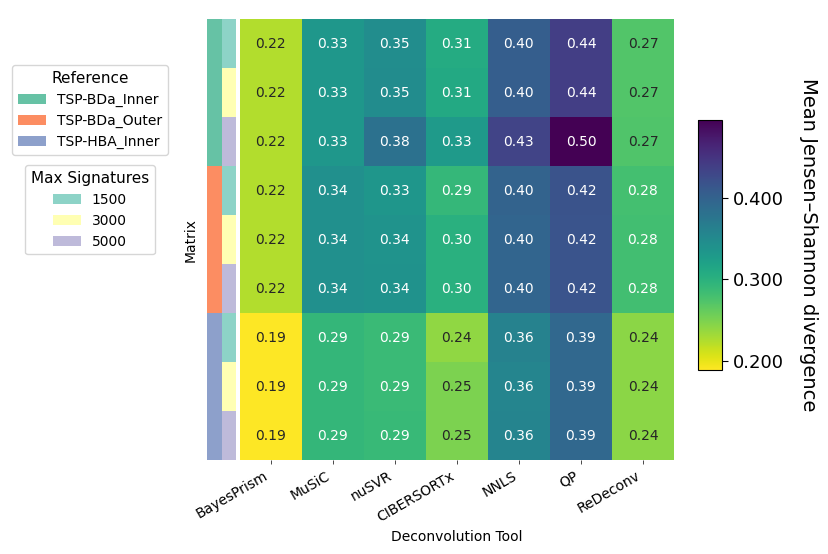

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ------------------ Load CSV ------------------
file_path = 'Results-JSD-PredictedVSActual/All_JSD_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# ------------------ Pivot for heatmap ------------------
heatmap_data = pd.pivot_table(
    df,
    index='Matrix',
    columns='Method',
    values='Mean_JS_divergence',
    aggfunc='mean'
)

# ------------------ Extract Reference + MaxSig from Matrix ------------------
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))

annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))

def get_maxsig(x):
    parts = x.split('_')
    if parts and parts[-1].isdigit():
        return int(parts[-1])
    return -1

annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Sort rows by Reference then MaxSig ------------------
heatmap_data = (
    heatmap_data
    .assign(Reference=annotations['Reference'], MaxSig=annotations['MaxSig'])
    .sort_values(['Reference', 'MaxSig'])
    .drop(columns=['Reference', 'MaxSig'])
)

# Recompute annotations aligned with sorted index
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))
annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))
annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Reorder columns ------------------
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
heatmap_data = heatmap_data.reindex(columns=method_order)

# ------------------ Palettes & LUTs ------------------
matrix_groups = sorted(annotations['Reference'].unique())
matrix_palette = sns.color_palette("Set2", n_colors=len(matrix_groups))
matrix_lut = dict(zip(matrix_groups, matrix_palette))

maxsig_keys = sorted(annotations['MaxSig'].unique())
maxsig_palette = sns.color_palette("Set3", n_colors=len(maxsig_keys))
maxsig_lut = dict(zip(maxsig_keys, maxsig_palette))

row_colors = pd.DataFrame({
    'Reference': [matrix_lut[g] for g in annotations['Reference']],
    'MaxSig': [maxsig_lut[k] for k in annotations['MaxSig']]
}, index=annotations.index)[['Reference', 'MaxSig']]

# ------------------ Fixed color normalization ------------------
# Adjust vmax depending on your JSD range
norm = Normalize(vmax=heatmap_data.max().max())

# ------------------ Plot clustermap ------------------
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    cmap='viridis_r',          # lower JSD = better
    figsize=(8, 5),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cbar_pos=None,
    linewidths=0,
    linecolor='white',
    dendrogram_ratio=(0.02, 0.02),
    norm=norm
)

# === Axis styling ===
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel("Matrix", labelpad=30, fontsize=10)
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.set_xlabel("Deconvolution Tool", fontsize=10)
g.ax_heatmap.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    labelbottom=True,
    length=3,
    width=0.5,
    labelsize=10
)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=30, ha="right")

# === Colorbar ===
cbar_ax = g.fig.add_axes([0.88, 0.23, 0.03, 0.5])
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)

cbar.ax.set_ylabel(
    "Mean Jensen–Shannon divergence",
    fontsize=14,
    rotation=270,
    labelpad=25
)
cbar.ax.tick_params(labelsize=13, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.3f}")
)

# === Legends ===
matrix_patches = [Patch(facecolor=matrix_lut[g], label=g) for g in matrix_groups]
maxsig_patches = [Patch(facecolor=maxsig_lut[k], label=str(k)) for k in maxsig_keys]

legend_ax1 = g.fig.add_axes([0.02, 0.65, 0.20, 0.20])
legend_ax1.axis('off')
legend_ax1.legend(
    handles=matrix_patches,
    title='Reference',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

legend_ax2 = g.fig.add_axes([0.02, 0.45, 0.20, 0.20])
legend_ax2.axis('off')
legend_ax2.legend(
    handles=maxsig_patches,
    title='Max Signatures',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

# Clean up row color axes
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])
g.ax_row_colors.set_xticklabels([])
g.ax_row_colors.set_yticklabels([])

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.25, right=0.85)

plt.show()
g.fig.savefig("Heatmap_Random_Mean_JSD_WithReference_MaxSig.svg",bbox_inches="tight")
plt.close(g.fig)

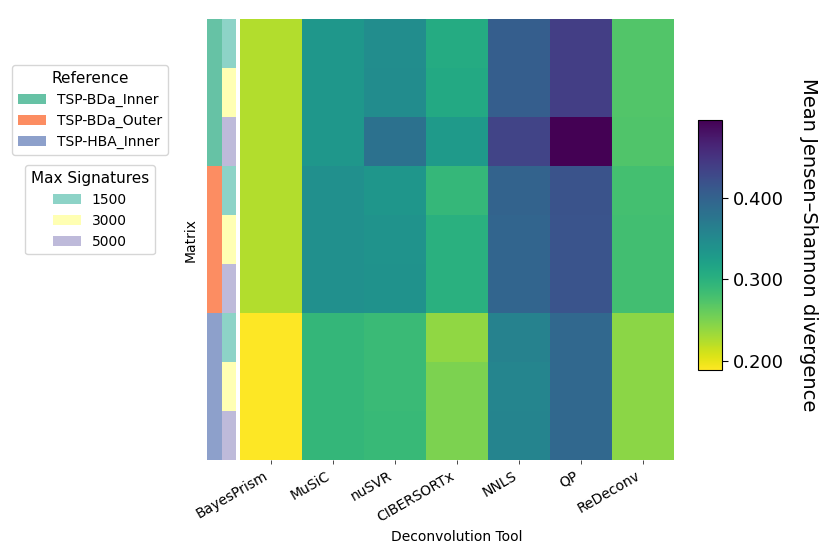

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ------------------ Load CSV ------------------
file_path = 'Results-JSD-PredictedVSActual/All_JSD_Summary.csv'
df = pd.read_csv(file_path, sep='\t')

# ------------------ Pivot for heatmap ------------------
heatmap_data = pd.pivot_table(
    df,
    index='Matrix',
    columns='Method',
    values='Mean_JS_divergence',
    aggfunc='mean'
)

# ------------------ Extract Reference + MaxSig from Matrix ------------------
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))

annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))

def get_maxsig(x):
    parts = x.split('_')
    if parts and parts[-1].isdigit():
        return int(parts[-1])
    return -1

annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Sort rows by Reference then MaxSig ------------------
heatmap_data = (
    heatmap_data
    .assign(Reference=annotations['Reference'], MaxSig=annotations['MaxSig'])
    .sort_values(['Reference', 'MaxSig'])
    .drop(columns=['Reference', 'MaxSig'])
)

# Recompute annotations aligned with sorted index
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))
annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))
annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Reorder columns ------------------
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
heatmap_data = heatmap_data.reindex(columns=method_order)

# ------------------ Palettes & LUTs ------------------
matrix_groups = sorted(annotations['Reference'].unique())
matrix_palette = sns.color_palette("Set2", n_colors=len(matrix_groups))
matrix_lut = dict(zip(matrix_groups, matrix_palette))

maxsig_keys = sorted(annotations['MaxSig'].unique())
maxsig_palette = sns.color_palette("Set3", n_colors=len(maxsig_keys))
maxsig_lut = dict(zip(maxsig_keys, maxsig_palette))

row_colors = pd.DataFrame({
    'Reference': [matrix_lut[g] for g in annotations['Reference']],
    'MaxSig': [maxsig_lut[k] for k in annotations['MaxSig']]
}, index=annotations.index)[['Reference', 'MaxSig']]

# ------------------ Fixed color normalization ------------------
# Adjust vmax depending on your JSD range
norm = Normalize(vmax=heatmap_data.max().max())

# ------------------ Plot clustermap ------------------
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    cmap='viridis_r',          # lower JSD = better
    figsize=(8, 5),
#    annot=True,
#    fmt=".2f",
#    annot_kws={"size": 10},
    cbar_pos=None,
    linewidths=0,
    linecolor='white',
    dendrogram_ratio=(0.02, 0.02),
    norm=norm
)

# === Axis styling ===
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel("Matrix", labelpad=30, fontsize=10)
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.set_xlabel("Deconvolution Tool", fontsize=10)
g.ax_heatmap.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    labelbottom=True,
    length=3,
    width=0.5,
    labelsize=10
)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=30, ha="right")

# === Colorbar ===
cbar_ax = g.fig.add_axes([0.88, 0.23, 0.03, 0.5])
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)

cbar.ax.set_ylabel(
    "Mean Jensen–Shannon divergence",
    fontsize=14,
    rotation=270,
    labelpad=25
)
cbar.ax.tick_params(labelsize=13, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.3f}")
)

# === Legends ===
matrix_patches = [Patch(facecolor=matrix_lut[g], label=g) for g in matrix_groups]
maxsig_patches = [Patch(facecolor=maxsig_lut[k], label=str(k)) for k in maxsig_keys]

legend_ax1 = g.fig.add_axes([0.02, 0.65, 0.20, 0.20])
legend_ax1.axis('off')
legend_ax1.legend(
    handles=matrix_patches,
    title='Reference',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

legend_ax2 = g.fig.add_axes([0.02, 0.45, 0.20, 0.20])
legend_ax2.axis('off')
legend_ax2.legend(
    handles=maxsig_patches,
    title='Max Signatures',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

# Clean up row color axes
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])
g.ax_row_colors.set_xticklabels([])
g.ax_row_colors.set_yticklabels([])

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.25, right=0.85)

plt.show()
g.fig.savefig("Heatmap_Random_Mean_JSD_Clean_WithReference_MaxSig.svg",bbox_inches="tight")
plt.close(g.fig)

## DECODE extension

The cells below repeat the preceding calculation and plotting workflow with `DECODE-PureTrue` and `DECODE-PureFalse` included as additional methods.
The metric definitions and calculations are unchanged.

In [ ]:
import os
import pandas as pd
import numpy as np
from glob import glob
from scipy.spatial.distance import jensenshannon

# === CONFIGURATION ===
root_dir = 'COO-Decon-Pseudobulks'
results_dir = os.path.join(root_dir, 'Results-JSD-PredictedVSActual')
os.makedirs(results_dir, exist_ok=True)

method_map = ['BayesPrism', 'nuSVR', 'ReDeconv', 'CIBERSORTx', 'MuSiC', 'NNLS', 'QP', 'DECODE-PureTrue', 'DECODE-PureFalse']

config_map = {
    "TSP-BDa_Outer_Random_v2C_New_All-Proportions.txt": [
        "TSP-BDa_Outer_300_1500_10-Random_v2",
        "TSP-BDa_Outer_1000_3000_10-Random_v2",
        "TSP-BDa_Outer_3000_5000_10-Random_v2"
    ],
    "TSP-BDa_Inner_Random_v2C_New_All-Proportions.txt": [
        "TSP-BDa_Inner_300_1500_10-Random_v2",
        "TSP-BDa_Inner_1000_3000_10-Random_v2",
        "TSP-BDa_Inner_3000_5000_10-Random_v2"
    ],
    "TSP-HBA_Inner_Random_v2C_New_All-Proportions.txt": [
        "TSP-HBA_Inner_300_1500_10-Random_v2",
        "TSP-HBA_Inner_1000_3000_10-Random_v2",
        "TSP-HBA_Inner_3000_5000_10-Random_v2"
    ]
}

all_results = []

# === MAIN LOOP ===
for prop_file, input_dirs in config_map.items():
    prop_path = os.path.join(root_dir, prop_file)

    print(f"\n=== Processing proportions file: {prop_file} ===")

    prop_df = pd.read_csv(prop_path, sep='\t', index_col=0)

    prop_df.index = prop_df.index.astype(str).str.strip()
    prop_df.columns = prop_df.columns.astype(str).str.strip()

    if "TotalCells" in prop_df.columns:
        prop_df = prop_df.drop(columns=["TotalCells"])

    prop_df = prop_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    prop_sums = prop_df.sum(axis=1)

    if (prop_sums == 0).any():
        print(f"Warning: {(prop_sums == 0).sum()} true-proportion rows sum to zero in {prop_file}")

    prop_df = (
        prop_df
        .div(prop_sums.replace(0, np.nan), axis=0)
        .multiply(100)
        .round(5)
        .fillna(0)
    )

    for input_dir in input_dirs:
        decon_dir = os.path.join(root_dir, input_dir)
        decon_files = sorted(glob(os.path.join(decon_dir, '*_modified.txt')))

        if not decon_files:
            print(f"No decon files found in {decon_dir}")
            continue

        for file_path in decon_files:
            try:
                filename = os.path.basename(file_path)
                raw_method = filename.replace('_modified.txt', '')
                method = next((m for m in method_map if m in raw_method), raw_method)

                # Load decon results
                decon_df = pd.read_csv(file_path, sep='\t', index_col=0)

                decon_df.index = decon_df.index.astype(str).str.strip()
                decon_df.columns = decon_df.columns.astype(str).str.strip()

                decon_df = decon_df.apply(pd.to_numeric, errors='coerce').fillna(0)

                # Align samples
                common_samples = prop_df.index.intersection(decon_df.index)

                if common_samples.empty:
                    print(f"No common samples in {file_path}")
                    continue

                # Identify column differences
                missing_in_decon = set(prop_df.columns) - set(decon_df.columns)
                missing_in_prop = set(decon_df.columns) - set(prop_df.columns)

                n_missing_in_decon = len(missing_in_decon)
                n_extra_in_decon = len(missing_in_prop)

                if missing_in_decon or missing_in_prop:
                    print(f"Column mismatch in {file_path}")
                    if missing_in_decon:
                        print(f"   Missing in decon: {missing_in_decon}")
                    if missing_in_prop:
                        print(f"   Missing in prop / extra in decon: {missing_in_prop}")

                # ============================================================
                # COLUMN ALIGNMENT FOR JSD
                # ============================================================
                # For MuSiC:
                #   Use the full expected cell-type space from prop_df.
                #   Missing expected MuSiC labels are added as predicted 0.
                #
                # For all other methods:
                #   Keep original behaviour: use only shared columns.
                # ============================================================

                if method == "MuSiC":
                    expected_cols = prop_df.columns

                    true_vals_df = prop_df.loc[common_samples, expected_cols].fillna(0)

                    pred_vals_df = (
                        decon_df
                        .reindex(index=common_samples, columns=expected_cols, fill_value=0)
                        .fillna(0)
                    )

                    if missing_in_decon:
                        print(f"   MuSiC missing labels added as 0 for JSD: {missing_in_decon}")

                else:
                    common_cols = prop_df.columns.intersection(decon_df.columns)

                    if common_cols.empty:
                        print(f"No matching columns in {file_path}")
                        continue

                    true_vals_df = prop_df.loc[common_samples, common_cols].fillna(0)
                    pred_vals_df = decon_df.loc[common_samples, common_cols].fillna(0)

                sample_jsd = []
                skipped_samples = 0

                for sample in common_samples:
                    true_vec = true_vals_df.loc[sample].values.astype(float)
                    pred_vec = pred_vals_df.loc[sample].values.astype(float)

                    true_vec = np.clip(true_vec, 0, None)
                    pred_vec = np.clip(pred_vec, 0, None)

                    true_sum = true_vec.sum()
                    pred_sum = pred_vec.sum()

                    if true_sum == 0 or pred_sum == 0:
                        skipped_samples += 1
                        continue

                    true_vec = true_vec / true_sum
                    pred_vec = pred_vec / pred_sum

                    # scipy returns Jensen-Shannon distance, so square it to get divergence
                    js_distance = jensenshannon(true_vec, pred_vec, base=2)
                    js_divergence = js_distance ** 2

                    sample_jsd.append(js_divergence)

                n_samples = len(sample_jsd)

                if n_samples == 0:
                    print(f"No valid samples for {input_dir} — {method}")
                    continue

                mean_jsd = np.mean(sample_jsd)
                median_jsd = np.median(sample_jsd)
                std_jsd = np.std(sample_jsd)
                min_jsd = np.min(sample_jsd)
                max_jsd = np.max(sample_jsd)

                print(
                    f"{prop_file} | {input_dir} | {method} — "
                    f"N={n_samples}, Skipped={skipped_samples}, "
                    f"Mean JSD={mean_jsd:.6f}, Median JSD={median_jsd:.6f}, SD={std_jsd:.6f}, "
                    f"MissingInDecon={n_missing_in_decon}, ExtraInDecon={n_extra_in_decon}"
                )

                all_results.append([
                    prop_file,
                    input_dir,
                    method,
                    mean_jsd,
                    median_jsd,
                    std_jsd,
                    min_jsd,
                    max_jsd,
                    n_samples,
                    skipped_samples,
                    n_missing_in_decon,
                    n_extra_in_decon
                ])

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# === SAVE SUMMARY ===
if all_results:
    results_df = pd.DataFrame(
        all_results,
        columns=[
            "ProportionsFile",
            "InputDir",
            "Method",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    )

    results_df["Matrix"] = results_df["InputDir"].apply(
        lambda x: "_".join(x.split("_")[0:4])
    )

    results_df = results_df[
        [
            "ProportionsFile",
            "Matrix",
            "Method",
            "Mean_JS_divergence",
            "Median_JS_divergence",
            "Std_JS_divergence",
            "Min_JS_divergence",
            "Max_JS_divergence",
            "N_samples",
            "Skipped_samples",
            "N_missing_in_decon",
            "N_extra_in_decon"
        ]
    ]

    results_csv = os.path.join(results_dir, "All_JSD_Summary_DECODE.csv")
    results_df.to_csv(results_csv, index=False, sep='\t')

    print(f"\nSaved JSD summary table: {results_csv}")

else:
    print("\nNo JSD results to save.")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# ------------------ Load CSV ------------------
file_path = 'Results-JSD-PredictedVSActual/All_JSD_Summary_DECODE.csv'
df = pd.read_csv(file_path, sep='\t')

# ------------------ Pivot for heatmap ------------------
heatmap_data = pd.pivot_table(
    df,
    index='Matrix',
    columns='Method',
    values='Mean_JS_divergence',
    aggfunc='mean'
)

# ------------------ Extract Reference + MaxSig from Matrix ------------------
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))

annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))

def get_maxsig(x):
    parts = x.split('_')
    if parts and parts[-1].isdigit():
        return int(parts[-1])
    return -1

annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Sort rows by Reference then MaxSig ------------------
heatmap_data = (
    heatmap_data
    .assign(Reference=annotations['Reference'], MaxSig=annotations['MaxSig'])
    .sort_values(['Reference', 'MaxSig'])
    .drop(columns=['Reference', 'MaxSig'])
)

# Recompute annotations aligned with sorted index
annotations = pd.DataFrame(index=heatmap_data.index)
idx_str = pd.Index(annotations.index.astype(str))
annotations['Reference'] = idx_str.map(lambda x: "_".join(x.split('_')[:2]))
annotations['MaxSig'] = idx_str.map(get_maxsig)

# ------------------ Reorder columns ------------------
method_order = ["BayesPrism", "MuSiC", "DECODE-PureTrue", "DECODE-PureFalse", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
heatmap_data = heatmap_data.reindex(columns=method_order)

# ------------------ Palettes & LUTs ------------------
matrix_groups = sorted(annotations['Reference'].unique())
matrix_palette = sns.color_palette("Set2", n_colors=len(matrix_groups))
matrix_lut = dict(zip(matrix_groups, matrix_palette))

maxsig_keys = sorted(annotations['MaxSig'].unique())
maxsig_palette = sns.color_palette("Set3", n_colors=len(maxsig_keys))
maxsig_lut = dict(zip(maxsig_keys, maxsig_palette))

row_colors = pd.DataFrame({
    'Reference': [matrix_lut[g] for g in annotations['Reference']],
    'MaxSig': [maxsig_lut[k] for k in annotations['MaxSig']]
}, index=annotations.index)[['Reference', 'MaxSig']]

# ------------------ Fixed color normalization ------------------
# Adjust vmax depending on your JSD range
norm = Normalize(vmax=heatmap_data.max().max())

# ------------------ Plot clustermap ------------------
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,
    col_cluster=False,
    row_cluster=False,
    cmap='viridis_r',          # lower JSD = better
    figsize=(8, 5),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cbar_pos=None,
    linewidths=0,
    linecolor='white',
    dendrogram_ratio=(0.02, 0.02),
    norm=norm
)

# === Axis styling ===
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel("Matrix", labelpad=30, fontsize=10)
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.set_xlabel("Deconvolution Tool", fontsize=10)
g.ax_heatmap.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    labelbottom=True,
    length=3,
    width=0.5,
    labelsize=10
)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=30, ha="right")

# === Colorbar ===
cbar_ax = g.fig.add_axes([0.88, 0.23, 0.03, 0.5])
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax)

cbar.ax.set_ylabel(
    "Mean Jensen–Shannon divergence",
    fontsize=14,
    rotation=270,
    labelpad=25
)
cbar.ax.tick_params(labelsize=13, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.3f}")
)

# === Legends ===
matrix_patches = [Patch(facecolor=matrix_lut[g], label=g) for g in matrix_groups]
maxsig_patches = [Patch(facecolor=maxsig_lut[k], label=str(k)) for k in maxsig_keys]

legend_ax1 = g.fig.add_axes([0.02, 0.65, 0.20, 0.20])
legend_ax1.axis('off')
legend_ax1.legend(
    handles=matrix_patches,
    title='Reference',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

legend_ax2 = g.fig.add_axes([0.02, 0.45, 0.20, 0.20])
legend_ax2.axis('off')
legend_ax2.legend(
    handles=maxsig_patches,
    title='Max Signatures',
    loc='center',
    fontsize=10,
    title_fontsize=11
)

# Clean up row color axes
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])
g.ax_row_colors.set_xticklabels([])
g.ax_row_colors.set_yticklabels([])

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.25, right=0.85)

plt.show()
g.fig.savefig("Heatmap_Random_Mean_JSD_WithReference_MaxSig_DECODE.svg",bbox_inches="tight")
plt.close(g.fig)